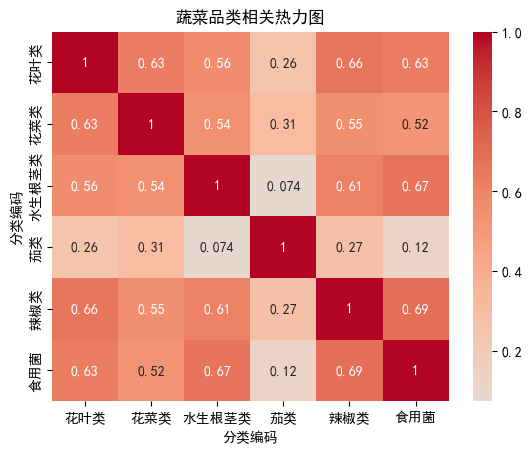

c:\Users\10041\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.draw()
C:\Users\10041\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


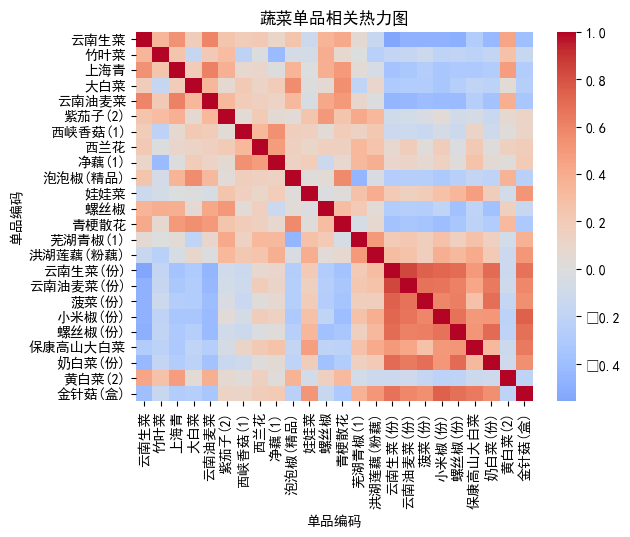

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'SimHei' 

# 读取附件1，附件2； 并创建单品编码/品类编码到对应名称的映射
item_df = pd.read_csv("附件1.csv", encoding="utf-8")
sale_df = pd.read_csv("附件2.csv", encoding="utf-8")
item_code_to_map = item_df.set_index('单品编码')['单品名称'].to_dict()
category_code_to_map = {
    1011010101 : "花叶类",
    1011010201 : "花菜类",
    1011010402 : "水生根茎类",
    1011010501 : "茄类",
    1011010504 : "辣椒类",
    1011010801 : "食用菌"
}

# 将为销量表添加每个销售的更多详细信息
sale_df = sale_df.merge(item_df[['单品编码', '分类编码', '分类名称']], on='单品编码', how='left')
# 创建每个单品的日销售总量
item_daily = sale_df.groupby(['销售日期', '单品编码'])['销量(千克)'].sum().reset_index()
# 创建每个品类的日销售总量
category_daily = sale_df.groupby(['销售日期', '分类编码'])['销量(千克)'].sum().reset_index()
#创建每一个单品的总销售量
item_total = item_daily.groupby(['单品编码'])['销量(千克)'].sum().reset_index()
item_total = item_total.merge(item_df[['单品编码', '单品名称']], on="单品编码")
item_total = item_total.sort_values('销量(千克)', ascending=False)



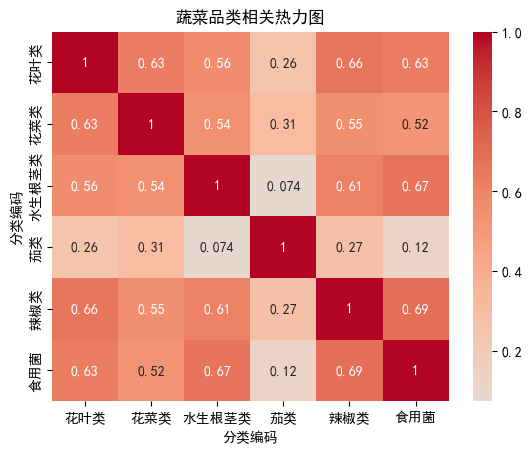

c:\Users\10041\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.draw()
C:\Users\10041\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


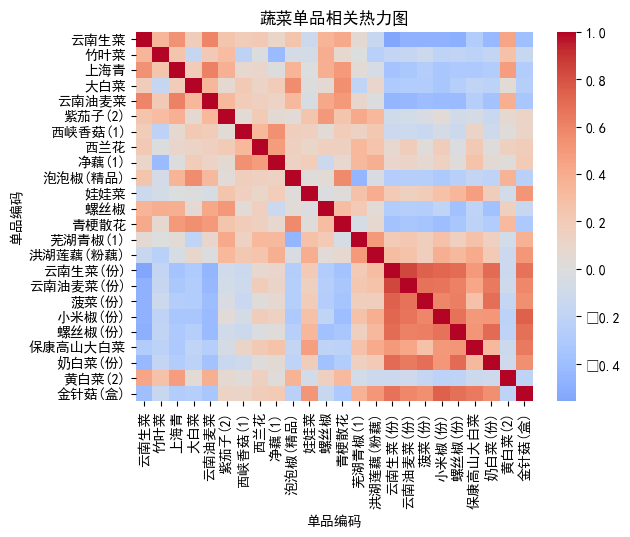

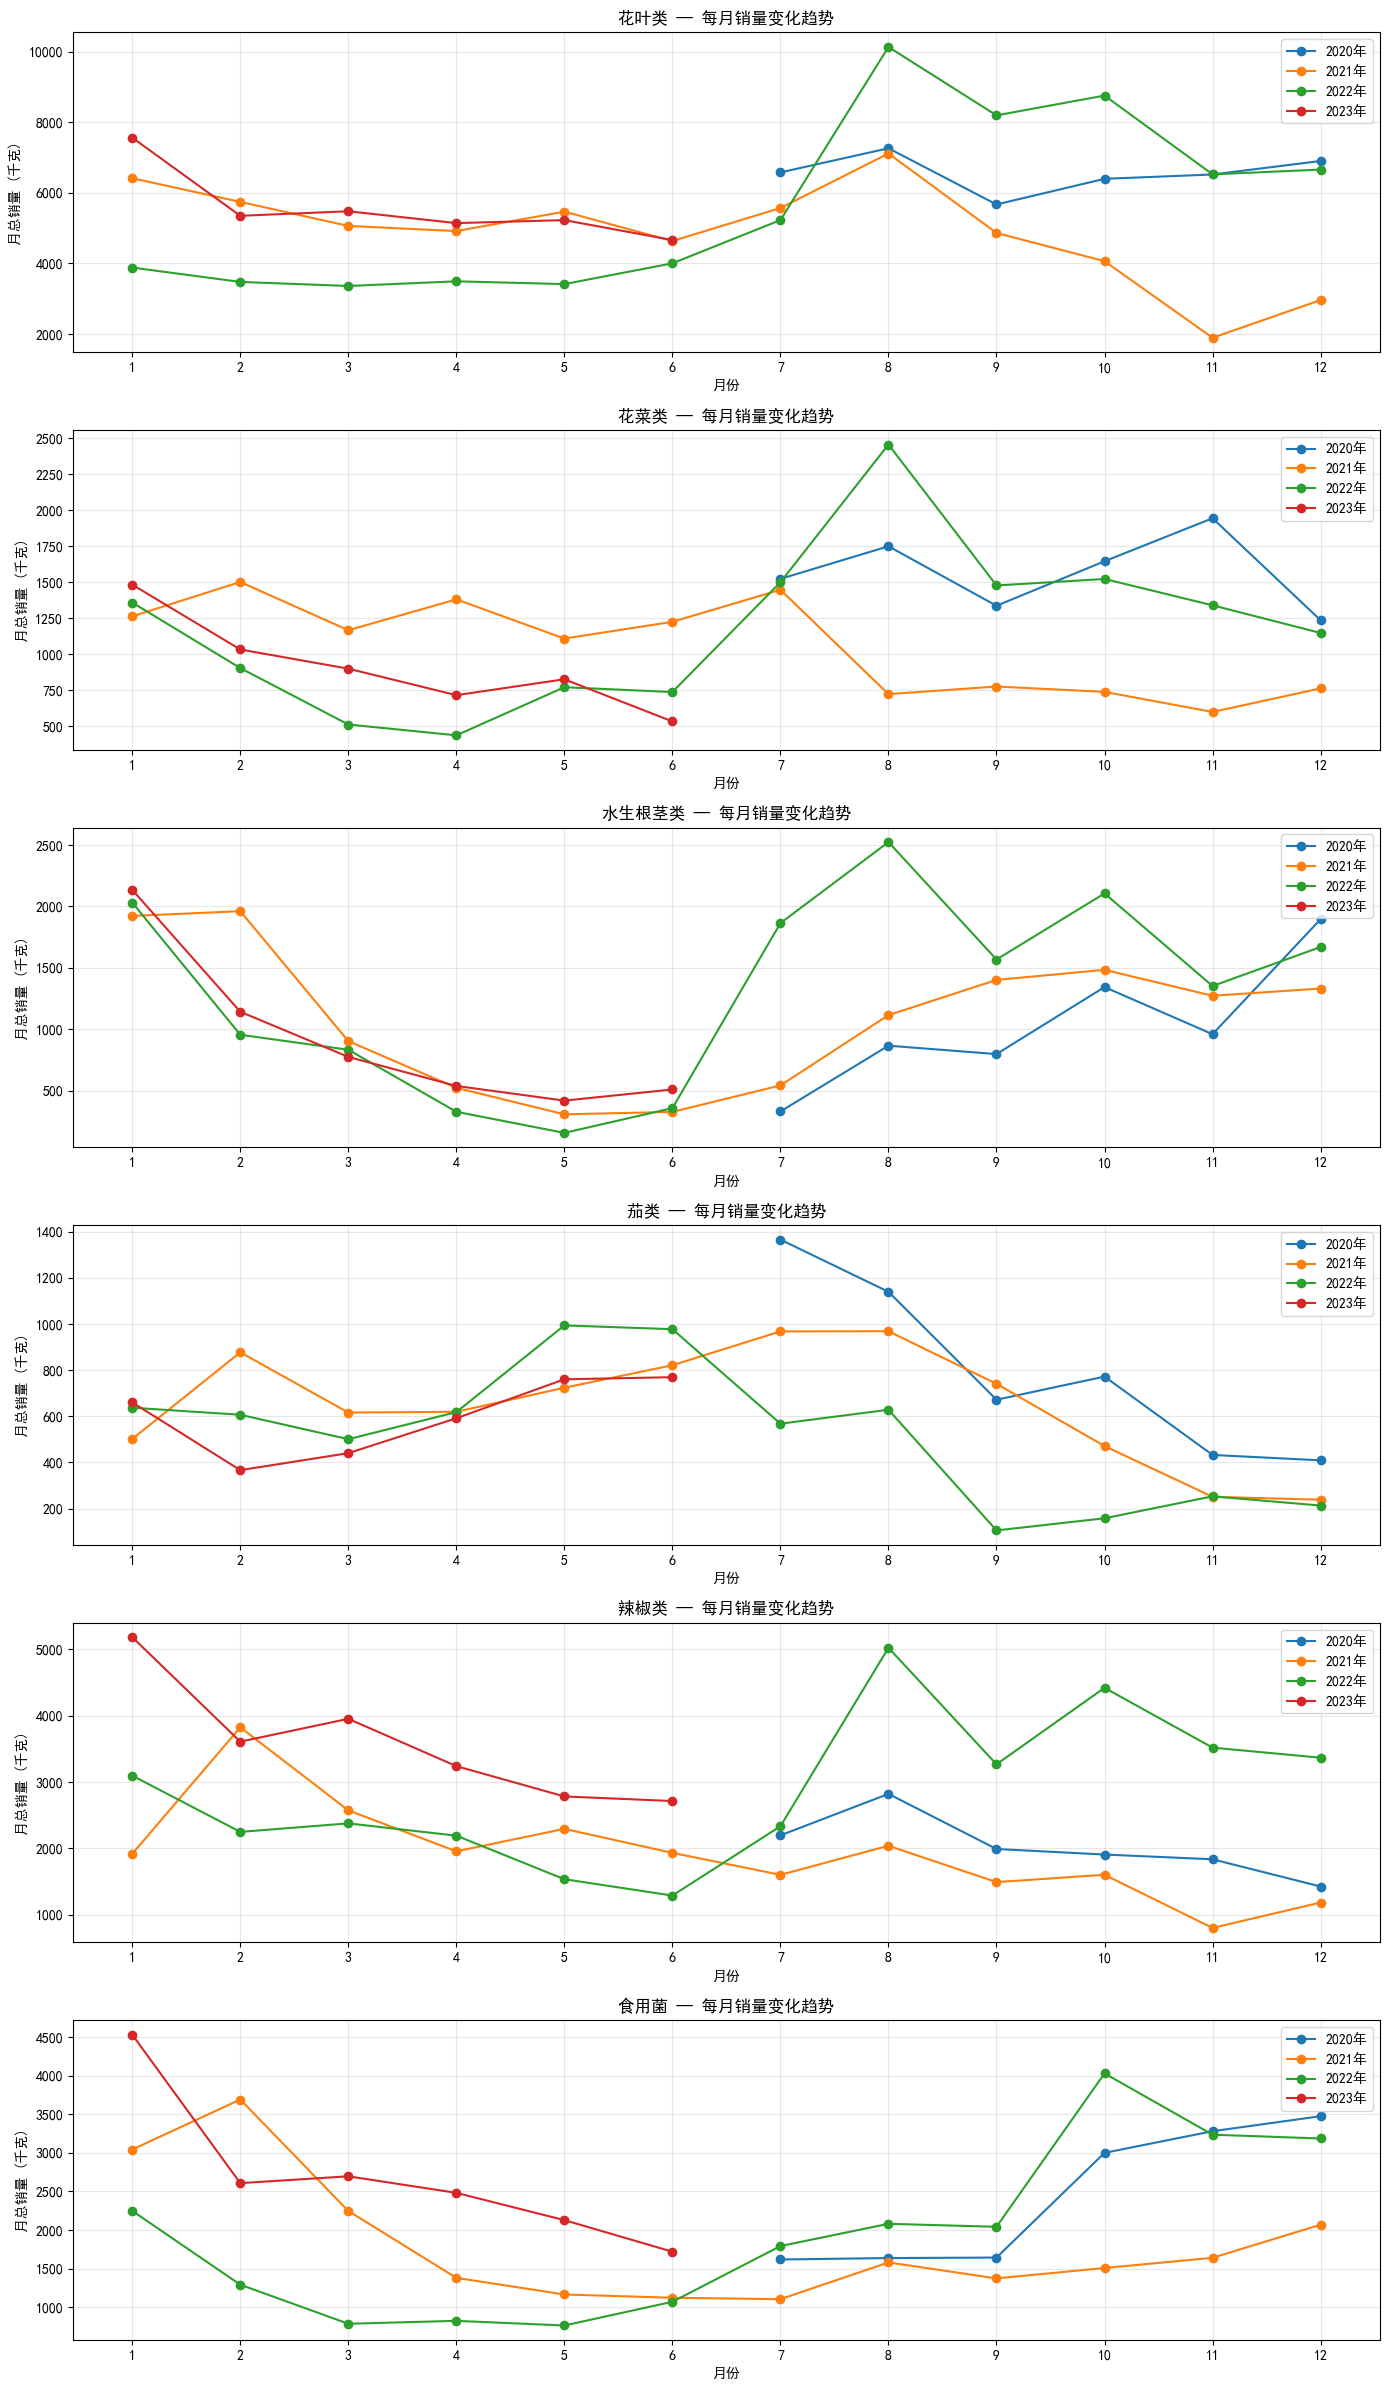

IndexError: index 3 is out of bounds for axis 0 with size 3

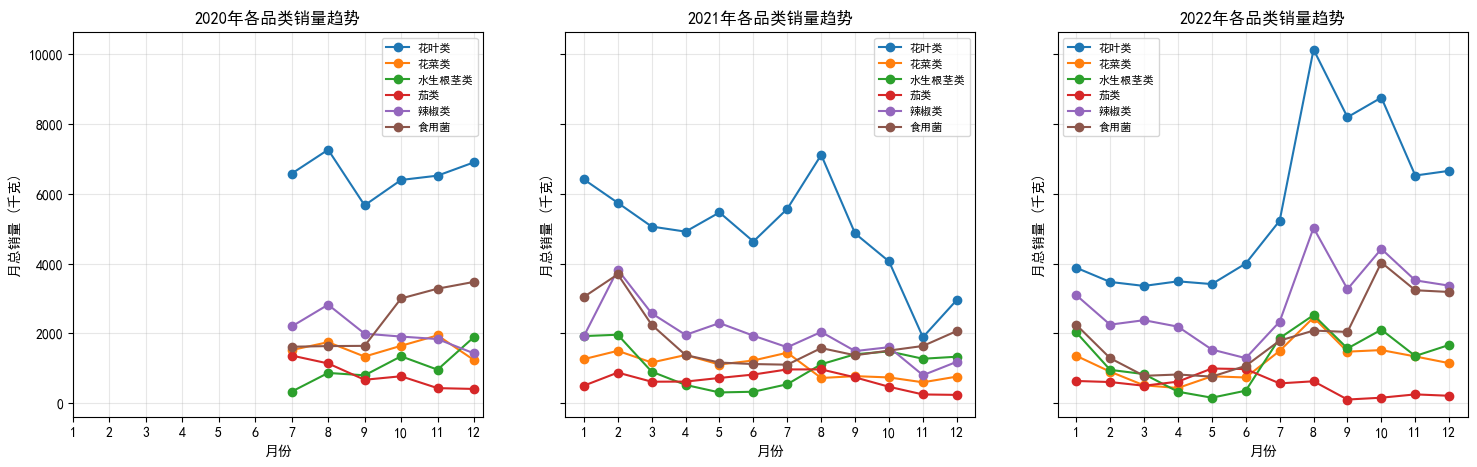

In [ ]:

# ============================================================
# 问题1：各品类/销量前20的子类的相关图和分布图
# ============================================================
category_daily['销售日期'] = pd.to_datetime(category_daily['销售日期'])
category_daily['年份'] = category_daily['销售日期'].dt.year
category_daily['月份'] = category_daily['销售日期'].dt.month

# 按年月+品类分组，计算月总销量
category_monthly = category_daily.groupby(['年份', '月份', '分类编码'])['销量(千克)'].sum().reset_index()

# 品类名称映射
category_monthly['品类名称'] = category_monthly['分类编码'].map(category_code_to_map)


# ----- 图1：不同品类的热力图 -----
categroy_pivot = category_daily.pivot(index='销售日期', columns='分类编码', values='销量(千克)').fillna(0)
categroy_corr_matrix = categroy_pivot.corr()
categroy_corr_matrix.index = categroy_corr_matrix.index.map(category_code_to_map)
categroy_corr_matrix.columns = categroy_corr_matrix.columns.map(category_code_to_map)

plt.Figure(figsize=(128, 64))
sns.heatmap(categroy_corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("蔬菜品类相关热力图")
plt.show()


# ---- 图2：销量前20的单品图 -----
top_item = item_total.head(24)['单品编码'].tolist()
item_daily_top = item_daily[item_daily['单品编码'].isin(top_item)]
item_pivot = item_daily_top.pivot(index="销售日期", columns="单品编码", values="销量(千克)").fillna(0)
item_corr_matrix = item_pivot.corr()
item_corr_matrix.index = item_corr_matrix.index.map(item_code_to_map)
item_corr_matrix.columns = item_corr_matrix.columns.map(item_code_to_map)

plt.Figure(figsize=(128, 64))
sns.heatmap(item_corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("蔬菜单品相关热力图")
plt.show()


# ----- 图3：每个品类一张子图，不同年份的曲线对比 -----
categories = category_monthly['分类编码'].unique()
n_cats = len(categories)

fig, axes = plt.subplots(n_cats, 1, figsize=(14, 4 * n_cats), sharex=False)

for i, (cat_code, cat_data) in enumerate(category_monthly.groupby('分类编码')):
    cat_name = category_code_to_map.get(cat_code, cat_code)
    ax = axes[i]
    for year, year_data in cat_data.groupby('年份'):
        year_data_sorted = year_data.sort_values('月份')
        ax.plot(year_data_sorted['月份'], year_data_sorted['销量(千克)'],
                marker='o', label=f'{year}年')
    ax.set_title(f'{cat_name} — 每月销量变化趋势', fontsize=12)
    ax.set_xlabel('月份')
    ax.set_ylabel('月总销量 (千克)')
    ax.set_xticks(range(1, 13))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ----- 图4：每年一张子图，所有品类曲线放在一起对比 -----
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for year_idx, (year, year_data) in enumerate(category_monthly.groupby('年份')):
    ax = axes2[year_idx]
    for cat_idx, (cat_code, cat_data) in enumerate(year_data.groupby('分类编码')):
        cat_name = category_code_to_map.get(cat_code, cat_code)
        cat_data_sorted = cat_data.sort_values('月份')
        ax.plot(cat_data_sorted['月份'], cat_data_sorted['销量(千克)'],
                marker='o', color=colors[cat_idx % len(colors)], label=cat_name)
    ax.set_title(f'{year}年各品类销量趋势', fontsize=12)
    ax.set_xlabel('月份')
    ax.set_ylabel('月总销量 (千克)')
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

建模数据量: 6474 条记录

花叶类: 最佳模型=linear, R²=0.0498
   销量 = 262.00 + (-12.66) × 价格
花菜类: 最佳模型=linear, R²=0.0828
   销量 = 63.49 + (-2.63) × 价格
水生根茎类: 最佳模型=linear, R²=0.0927
   销量 = 63.66 + (-2.53) × 价格
茄类: 最佳模型=linear, R²=0.0333
   销量 = 29.96 + (-0.97) × 价格
辣椒类: 最佳模型=linear, R²=0.0130
   销量 = 98.45 + (-1.37) × 价格
食用菌: 最佳模型=linear, R²=0.1232
   销量 = 148.19 + (-6.43) × 价格


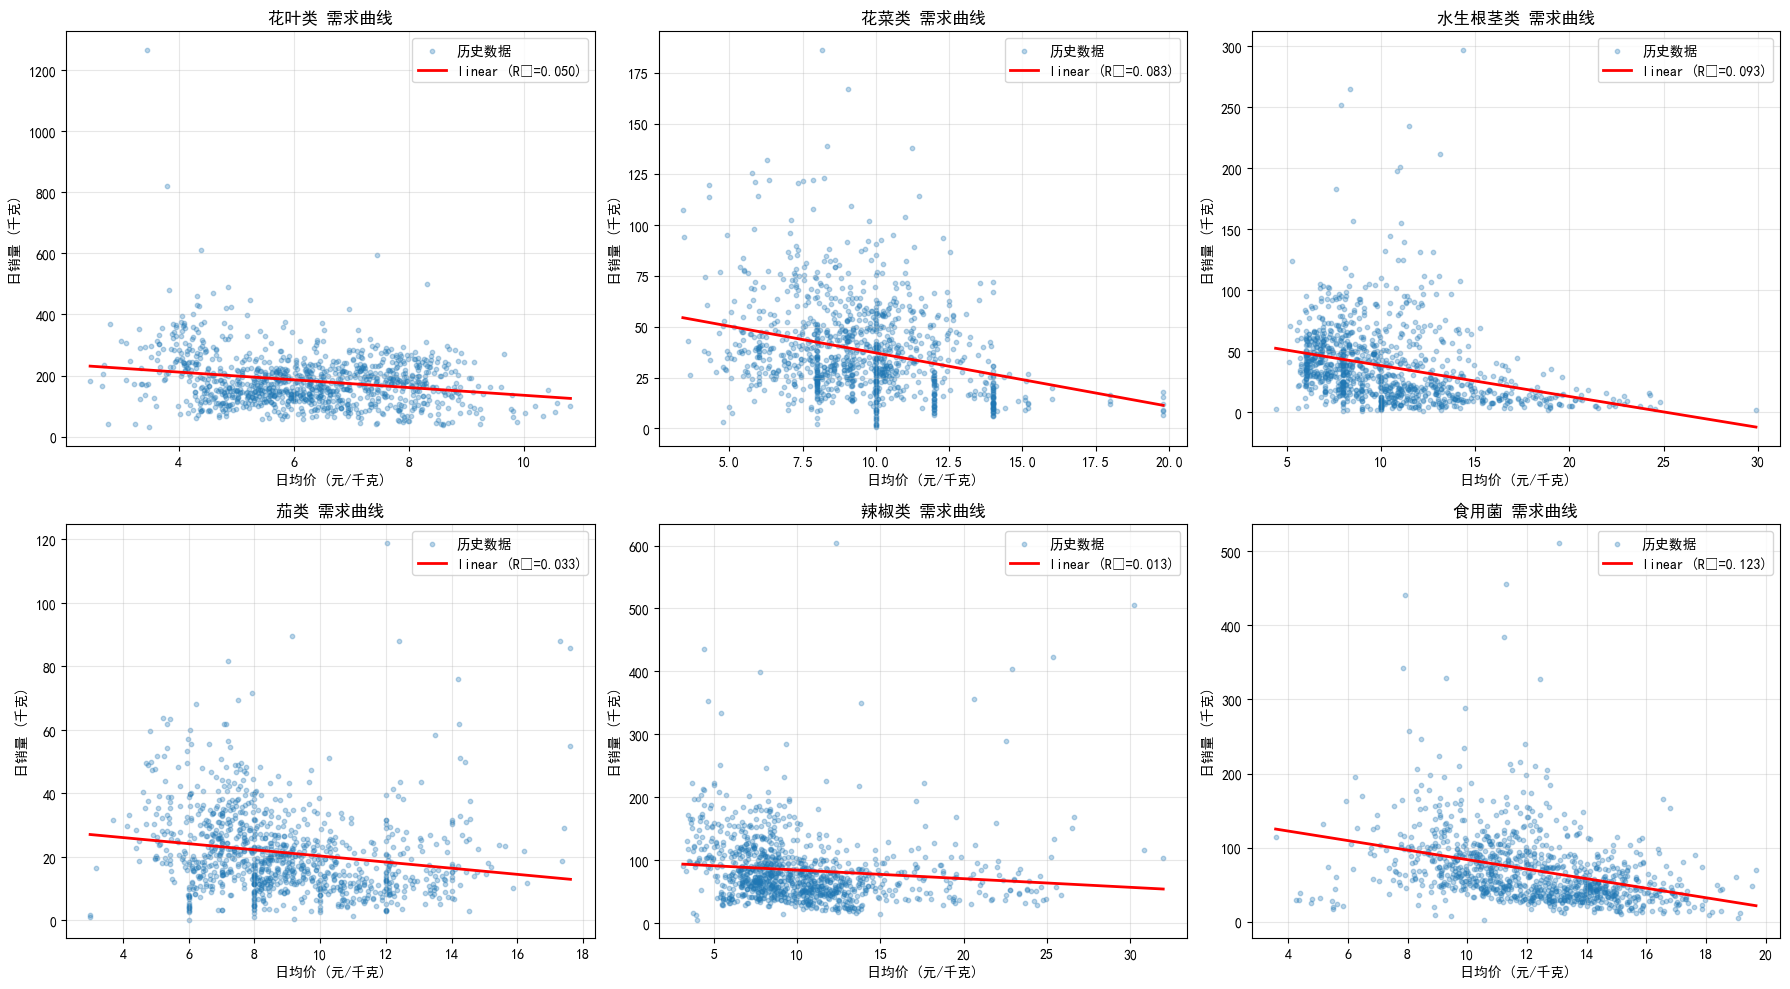


注：需求弹性为负表示价格上涨 → 销量下降，符合经济规律。
若弹性 < -1 表示富有弹性， > -1 表示缺乏弹性。

===== 各品类预测单位成本（基于6月最后一周批发价）=====
  品类名称  批发价格(元/千克)  损耗率  单位成本
    花叶类           3.930106  0.1283  4.508554
    花菜类           8.395952  0.1551  9.937214
水生根茎类          11.654986  0.1365 13.497379
      茄类           4.698214  0.0668  5.034520
    辣椒类           6.095580  0.0924  6.716152
    食用菌           4.666155  0.0945  5.153126

  各品类最优定价与日补货量（策略基准）
         品类  单位成本(元/千克)  最优定价(元/千克)  日补货量(千克)  预计日利润(元)
1      花叶类               4.51              12.60           102.5           829.0
2      花菜类               9.94              17.02            18.7           132.0
3  水生根茎类              13.50              19.32            14.7            86.0
4        茄类               5.03              18.03            12.5           163.0
5      辣椒类               6.72              39.29            44.6          1454.0
6      食用菌               5.15              14.11            57.5           515.0

  未来一周（2023年7月1日 - 7月7日）每日补货量与定价策略

--- 每

In [44]:
# ============================================================
# 问题2：以品类为单位的日补货量与定价策略优化
# ============================================================
import numpy as np
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

# ----- 1. 数据准备 -----
# 读取损耗率表
loss_df = pd.read_excel('附件4.xlsx')
loss_df.columns = ['分类编码', '分类名称', '损耗率']
loss_df['损耗率'] = loss_df['损耗率'] / 100  # 转为小数
loss_dict = loss_df.set_index('分类编码')['损耗率'].to_dict()

# 品类映射（保持与前面一致）
category_name_map = {
    1011010101: '花叶类', 1011010201: '花菜类',
    1011010402: '水生根茎类', 1011010501: '茄类',
    1011010504: '辣椒类', 1011010801: '食用菌'
}

# 读取批发价数据
wholesale = pd.read_excel('附件3.xlsx')
wholesale['日期'] = pd.to_datetime(wholesale['日期'])

# 合并品类信息到批发价
wholesale = wholesale.merge(item_df[['单品编码', '分类编码']], on='单品编码', how='left')

# 按品类-日期聚合批发价（单品均值作为品类批发价）
wholesale_cat = wholesale.groupby(['日期', '分类编码'])['批发价格(元/千克)'].mean().reset_index()
wholesale_cat['品类名称'] = wholesale_cat['分类编码'].map(category_name_map)

# 合并日销售数据与批发价
sale_daily = sale_df.groupby(['销售日期', '分类编码']).agg(
    日销量=('销量(千克)', 'sum'),
    日均价=('销售单价(元/千克)', 'mean')
).reset_index()
sale_daily['销售日期'] = pd.to_datetime(sale_daily['销售日期'])

# 合并批发价和损耗率
model_data = sale_daily.merge(
    wholesale_cat[['日期', '分类编码', '批发价格(元/千克)']],
    left_on=['销售日期', '分类编码'],
    right_on=['日期', '分类编码'],
    how='left'
)
model_data['损耗率'] = model_data['分类编码'].map(loss_dict)
model_data['单位成本'] = model_data['批发价格(元/千克)'] / (1 - model_data['损耗率'])
model_data['品类名称'] = model_data['分类编码'].map(category_name_map)
model_data = model_data.dropna(subset=['单位成本', '日均价', '日销量'])

print(f'建模数据量: {len(model_data)} 条记录')
print()

# ----- 2. 品类需求-价格关系建模 -----
# 为每个品类拟合需求曲线: 日销量 = f(日均价)
# 使用两种模型: 线性模型 和 对数-对数模型（弹性模型）

demand_models = {}  # 存储每个品类的最优模型参数

fig3, axes3 = plt.subplots(2, 3, figsize=(18, 10))
axes3 = axes3.flatten()

for i, (cat_code, cat_name) in enumerate(category_name_map.items()):
    cat_data = model_data[model_data['分类编码'] == cat_code].copy()
    
    # ---- 线性模型: 销量 = a + b * 价格 ----
    A = np.vstack([cat_data['日均价'], np.ones(len(cat_data))]).T
    b_lin, a_lin = np.linalg.lstsq(A, cat_data['日销量'], rcond=None)[0]
    r2_lin = 1 - np.sum((cat_data['日销量'] - (a_lin + b_lin * cat_data['日均价']))**2) / \
                  np.sum((cat_data['日销量'] - cat_data['日销量'].mean())**2)
    
    # ---- 对数-对数模型: ln(销量) = ln(a) + b * ln(价格) ----
    valid = (cat_data['日均价'] > 0) & (cat_data['日销量'] > 0)
    log_price = np.log(cat_data.loc[valid, '日均价'])
    log_vol = np.log(cat_data.loc[valid, '日销量'])
    A_log = np.vstack([log_price, np.ones(len(log_price))]).T
    b_log, ln_a = np.linalg.lstsq(A_log, log_vol, rcond=None)[0]
    a_log = np.exp(ln_a)
    
    # 对数模型的R²
    pred_log = a_log * (cat_data.loc[valid, '日均价'] ** b_log)
    r2_log = 1 - np.sum((cat_data.loc[valid, '日销量'] - pred_log)**2) / \
                  np.sum((cat_data.loc[valid, '日销量'] - cat_data.loc[valid, '日销量'].mean())**2)
    
    # 选择R²更高的模型
    if r2_lin >= r2_log:
        best_model = 'linear'
        params = {'a': a_lin, 'b': b_lin}
        r2_best = r2_lin
    else:
        best_model = 'loglog'
        params = {'a': a_log, 'b': b_log}
        r2_best = r2_log
    
    demand_models[cat_code] = {'type': best_model, 'params': params, 'R2': r2_best}
    
    print(f'{cat_name}: 最佳模型={best_model}, R²={r2_best:.4f}')
    if best_model == 'linear':
        print(f'   销量 = {params["a"]:.2f} + ({params["b"]:.2f}) × 价格')
    else:
        print(f'   销量 = {params["a"]:.2f} × 价格^{params["b"]:.2f} (弹性={params["b"]:.2f})')
    
    # 绘制散点和拟合曲线
    ax = axes3[i]
    ax.scatter(cat_data['日均价'], cat_data['日销量'], alpha=0.3, s=10, label='历史数据')
    price_range = np.linspace(cat_data['日均价'].min(), cat_data['日均价'].max(), 100)
    if best_model == 'linear':
        pred = params['a'] + params['b'] * price_range
    else:
        pred = params['a'] * (price_range ** params['b'])
    ax.plot(price_range, pred, 'r-', linewidth=2, label=f'{best_model} (R²={r2_best:.3f})')
    ax.set_title(f'{cat_name} 需求曲线', fontsize=12)
    ax.set_xlabel('日均价 (元/千克)')
    ax.set_ylabel('日销量 (千克)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n' + '='*80)
print('注：需求弹性为负表示价格上涨 → 销量下降，符合经济规律。')
print('若弹性 < -1 表示富有弹性， > -1 表示缺乏弹性。')
print('='*80)

# ----- 3. 未来一周成本预测 -----
# 用6月最后一周（6月24-30日）的平均批发价作为7月1-7日的成本估计
latest_week = wholesale_cat[
    (wholesale_cat['日期'] >= '2023-06-24') & 
    (wholesale_cat['日期'] <= '2023-06-30')
]
future_cost = latest_week.groupby('分类编码')['批发价格(元/千克)'].mean().reset_index()
future_cost['品类名称'] = future_cost['分类编码'].map(category_name_map)
future_cost['损耗率'] = future_cost['分类编码'].map(loss_dict)
future_cost['单位成本'] = future_cost['批发价格(元/千克)'] / (1 - future_cost['损耗率'])

print('\n===== 各品类预测单位成本（基于6月最后一周批发价）=====')
print(future_cost[['品类名称', '批发价格(元/千克)', '损耗率', '单位成本']].to_string(index=False))

# ----- 4. 利润优化 -----
# 对每个品类，计算最优定价和补货量
# 利润(price) = (price - cost) × demand(price)

results = []
for _, row in future_cost.iterrows():
    cat_code = row['分类编码']
    cat_name = row['品类名称']
    cost = row['单位成本']
    model = demand_models[cat_code]
    
    if model['type'] == 'linear':
        a = model['params']['a']
        b = model['params']['b']
        # 利润(P) = (P - C)(a + bP) = bP² + (a - bC)P - aC
        # dProfit/dP = 2bP + (a - bC) = 0 → P = (bC - a) / (2b)
        if b < 0:  # 正常需求曲线，价格上升销量下降
            opt_price = (a - b * cost) / (-2 * b)
        else:
            opt_price = cost * 1.3  # 如果拟合异常，用成本加成30%
        
        opt_demand = max(0, a + b * opt_price)
        opt_profit = (opt_price - cost) * opt_demand
    
    else:  # loglog
        a = model['params']['a']
        b = model['params']['b']
        # Q = a × P^b
        # Profit = (P - C) × a × P^b
        # dProfit/dP = a × P^(b-1) × [(b+1)P - bC] = 0
        # → P = bC / (b+1),  需要 b < -1
        if b < -1:
            opt_price = b * cost / (b + 1)
        else:
            # 缺乏弹性，取一个合理的高价（成本+50%或历史95分位价）
            hist_prices = model_data[model_data['分类编码'] == cat_code]['日均价']
            max_reasonable = hist_prices.quantile(0.95)
            opt_price = min(cost * 1.5, max_reasonable)
        
        if opt_price > cost:
            opt_demand = max(0, a * (opt_price ** b))
            opt_profit = (opt_price - cost) * opt_demand
        else:
            opt_price = cost * 1.2
            opt_demand = max(0, a * (opt_price ** b))
            opt_profit = (opt_price - cost) * opt_demand
    
    results.append({
        '品类': cat_name,
        '单位成本(元/千克)': round(cost, 2),
        '最优定价(元/千克)': round(opt_price, 2),
        '日补货量(千克)': round(opt_demand, 1),
        '预计日利润(元)': round(opt_profit, 0)
    })

result_df = pd.DataFrame(results)
result_df.index = result_df.index + 1
print('\n' + '='*80)
print('  各品类最优定价与日补货量（策略基准）')
print('='*80)
print(result_df.to_string())

# ----- 5. 生成未来一周(7月1-7日)每日策略 -----
print('\n' + '='*100)
print('  未来一周（2023年7月1日 - 7月7日）每日补货量与定价策略')
print('='*100)

# 考虑周内效应：根据历史数据计算各品类的周内销量系数
model_data['星期'] = model_data['销售日期'].dt.dayofweek  # 0=周一
weekly_pattern = model_data.groupby(['分类编码', '星期'])['日销量'].mean().reset_index()
weekly_pattern.columns = ['分类编码', '星期', '平均日销量']

# 计算各品类周内各天的销量相对比例
weekly_ratios = {}
for cat_code in category_name_map.keys():
    cat_w = weekly_pattern[weekly_pattern['分类编码'] == cat_code].copy()
    avg_all = cat_w['平均日销量'].mean()
    cat_w['系数'] = cat_w['平均日销量'] / avg_all
    weekly_ratios[cat_code] = dict(zip(cat_w['星期'], cat_w['系数']))

week_dates = pd.date_range('2023-07-01', '2023-07-07')
week_strategy = []

for d, date in enumerate(week_dates):
    weekday = date.weekday()
    for _, row in result_df.iterrows():
        cat_code = future_cost[future_cost['品类名称'] == row['品类']]['分类编码'].values[0]
        ratio = weekly_ratios[cat_code].get(weekday, 1.0)
        adj_demand = row['日补货量(千克)'] * ratio
        # 补货量需考虑损耗：上架量 = 预期销量 / (1 - 损耗率)
        loss_rate = loss_dict[cat_code]
        replenish = adj_demand / (1 - loss_rate)
        
        week_strategy.append({
            '日期': date.strftime('%Y-%m-%d'),
            '星期': ['周一', '周二', '周三', '周四', '周五', '周六', '周日'][weekday],
            '品类': row['品类'],
            '定价(元/千克)': row['最优定价(元/千克)'],
            '预期销量(千克)': round(adj_demand, 1),
            '补货量(千克)': round(replenish, 1),
            '预期利润(元)': round((row['最优定价(元/千克)'] - row['单位成本(元/千克)']) * adj_demand, 0)
        })

strategy_df = pd.DataFrame(week_strategy)
pivot_price = strategy_df.pivot(index='品类', columns='日期', values='定价(元/千克)')
pivot_replenish = strategy_df.pivot(index='品类', columns='日期', values='补货量(千克)')
pivot_profit = strategy_df.pivot(index='品类', columns='日期', values='预期利润(元)')

print('\n--- 每日定价策略 (元/千克) ---')
print(pivot_price.to_string())
print('\n--- 每日补货量 (千克) ---')
print(pivot_replenish.to_string())
print('\n--- 每日预期利润 (元) ---')
print(pivot_profit.to_string())

total_profit = strategy_df['预期利润(元)'].sum()
print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  未来一周总预期利润: {total_profit:.0f} 元')
print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

print('\n策略说明:')
print('1. 定价基于历史需求-价格关系模型优化，目标为最大化利润')
print('2. 单位成本 = 批发价 / (1 - 损耗率)，反映了实际销售成本')
print('3. 补货量 = 预期销量 / (1 - 损耗率)，考虑了运输和陈列损耗')
print('4. 周内波动根据历史周度模式调整')


In [47]:
# ============================================================
# 问题3：空间有限的单品补货与定价策略（7月1日）
# ============================================================

# ----- 1. 确定6月24-30日的可售品种 -----
sale_df['销售日期'] = pd.to_datetime(sale_df['销售日期'])
wholesale['日期'] = pd.to_datetime(wholesale['日期'])

jun_sale = sale_df[(sale_df['销售日期'] >= '2023-06-24') & (sale_df['销售日期'] <= '2023-06-30')]
jun_ws = wholesale[(wholesale['日期'] >= '2023-06-24') & (wholesale['日期'] <= '2023-06-30')]

sold_items = set(jun_sale['单品编码'].unique())
ws_items = set(jun_ws['单品编码'].unique())
avail_items = sorted(sold_items & ws_items)
print(f'可售单品总数: {len(avail_items)}')

avail_df = item_df[item_df['单品编码'].isin(avail_items)].copy()
avail_df['品类名称'] = avail_df['分类编码'].map(category_code_to_map)
print('各品类可售数:')
print(avail_df.groupby('品类名称')['单品编码'].nunique(), '\n')

# ----- 2. 品类销售贡献度与单品数分配 -----
total_cat_sales = category_daily.groupby('分类编码')['销量(千克)'].sum()
total_all_sales = total_cat_sales.sum()
sales_share = total_cat_sales / total_all_sales

base_quota = (33 * sales_share).round().astype(int)
for cat_code in base_quota.index:
    avail_count = len(avail_df[avail_df['分类编码'] == cat_code])
    base_quota[cat_code] = max(1, min(base_quota[cat_code], avail_count))

while base_quota.sum() < 33:
    deficit = []
    for cat_code in base_quota.index:
        avail_count = len(avail_df[avail_df['分类编码'] == cat_code])
        if base_quota[cat_code] < avail_count:
            deficit.append((sales_share[cat_code] - base_quota[cat_code]/33, cat_code))
    if not deficit:
        break
    deficit.sort(reverse=True)
    base_quota[deficit[0][1]] += 1

while base_quota.sum() > 33:
    surplus = [(base_quota[cat]/33 - sales_share[cat], cat) for cat in base_quota.index if base_quota[cat] > 1]
    surplus.sort(reverse=True)
    base_quota[surplus[0][1]] -= 1

print('各品类分配单品数:')
for cat_code in base_quota.index:
    print(f'  {category_code_to_map[cat_code]}: {base_quota[cat_code]} 个')
print(f'  总计: {base_quota.sum()} 个\n')

# ----- 3. 单品评分与选择 -----
item_scores = {}
for cat_code in base_quota.index:
    cat_name = category_code_to_map[cat_code]
    cat_avail = avail_df[avail_df['分类编码'] == cat_code].copy()

    scores = []
    for _, row in cat_avail.iterrows():
        pid = row['单品编码']
        s = sale_df[sale_df['单品编码'] == pid]
        total_sales = s['销量(千克)'].sum()
        avg_daily_sales = s['销量(千克)'].mean()
        sales_days = s['销售日期'].nunique()
        total_days = (sale_df['销售日期'].max() - sale_df['销售日期'].min()).days
        stability = sales_days / total_days if total_days > 0 else 0

        p_ws = wholesale[wholesale['单品编码'] == pid]
        avg_ws = p_ws[p_ws['日期'] >= '2023-06-24']['批发价格(元/千克)'].mean()
        if pd.isna(avg_ws):
            avg_ws = p_ws['批发价格(元/千克)'].mean()
        loss_rate = loss_dict.get(cat_code, 0.1)
        cost = avg_ws / (1 - loss_rate) if not pd.isna(avg_ws) else 0
        avg_price = s['销售单价(元/千克)'].mean()
        margin = (avg_price - cost) / cost if cost > 0 else 0

        scores.append({
            '单品编码': pid, '单品名称': row['单品名称'],
            '总销量': total_sales, '日均销量': avg_daily_sales,
            '毛利率': margin, '稳定度': stability,
            '平均售价': avg_price, '成本': cost, '批发价': avg_ws
        })

    score_df = pd.DataFrame(scores)
    if len(score_df) == 0:
        continue

    for col in ['总销量', '毛利率', '稳定度']:
        min_v, max_v = score_df[col].min(), score_df[col].max()
        if max_v > min_v:
            score_df[f'{col}_分'] = (score_df[col] - min_v) / (max_v - min_v)
        else:
            score_df[f'{col}_分'] = 0.5

    score_df['综合分'] = (score_df['总销量_分'] * 0.40 +
                         score_df['毛利率_分'] * 0.35 +
                         score_df['稳定度_分'] * 0.25)

    score_df = score_df.sort_values('综合分', ascending=False)
    n_select = min(base_quota[cat_code], len(score_df))
    selected = score_df.head(n_select).copy()

    selected['调整毛利率'] = selected.apply(
        lambda r: 0.3 if r['毛利率'] < 0 and r['成本'] > 0 else r['毛利率'], axis=1
    )

    item_scores[cat_code] = {
        'all': score_df,
        'selected': selected,
        'n_selected': n_select
    }

    print(f'\n{cat_name}（选{n_select}个）:')
    for _, r in selected.iterrows():
        print(f'  {r["单品名称"]}: 日均销={r["日均销量"]:.1f}kg, 毛利率={r["毛利率"]*100:.0f}%, '
              f'成本={r["成本"]:.2f}, 均价={r["平均售价"]:.2f}, 评分={r["综合分"]:.3f}')

# ----- 4. 品类层级汇总 -----
selected_items = []
selected_cat_items = {}
for cat_code, data in item_scores.items():
    items = data['selected']
    selected_cat_items[cat_code] = items
    for _, r in items.iterrows():
        selected_items.append({
            '单品编码': r['单品编码'], '单品名称': r['单品名称'],
            '分类编码': cat_code, '品类名称': category_code_to_map[cat_code],
            '成本': r['成本'], '批发价': r['批发价'],
            '历史均价': r['平均售价']
        })

selected_df = pd.DataFrame(selected_items)
print(f'\n\n共选择 {len(selected_df)} 个单品')

# ----- 5. 单品定价与补货量确定 -----
cat_markup = {}
for _, row in result_df.iterrows():
    for cat_code, cat_name in category_code_to_map.items():
        if cat_name == row['品类']:
            unit_cost = row['单位成本(元/千克)']
            opt_price = row['最优定价(元/千克)']
            cat_markup[cat_code] = (opt_price / unit_cost)
            break

print('\n品类加价率:')
for cat_code, markup in cat_markup.items():
    print(f'  {category_code_to_map[cat_code]}: {markup:.2f}倍')

july1_strategy = []
for cat_code in base_quota.index:
    cat_items = selected_cat_items[cat_code]
    if len(cat_items) == 0:
        continue

    markup = cat_markup.get(cat_code, 1.3)
    cat_opt = result_df[result_df['品类'] == category_code_to_map[cat_code]]
    cat_demand = cat_opt.iloc[0]['日补货量(千克)'] if len(cat_opt) > 0 else \
                 category_daily[category_daily['分类编码'] == cat_code]['销量(千克)'].mean()

    items_with_sales = []
    for _, r in cat_items.iterrows():
        pid = r['单品编码']
        hist = sale_df[sale_df['单品编码'] == pid]['销量(千克)']
        recent = sale_df[(sale_df['单品编码'] == pid) & (sale_df['销售日期'] >= '2023-04-01')]['销量(千克)']
        recent_avg = recent.mean() if len(recent) > 0 else hist.mean()
        items_with_sales.append({**r.to_dict(), '近期日均': recent_avg})

    items_df = pd.DataFrame(items_with_sales)
    total_avg = items_df['近期日均'].sum()
    items_df['分配比例'] = items_df['近期日均'] / total_avg if total_avg > 0 else 1 / len(items_df)

    for _, r in items_df.iterrows():
        cost = r['成本']
        base_price = cost * markup
        hist_price = r['平均售价']
        max_price = hist_price * 1.2 if hist_price > 0 else base_price * 1.3
        min_price = cost * 1.05
        final_price = max(min_price, min(base_price, max_price))

        demand = max(cat_demand * r['分配比例'], 2.5)
        loss_rate = loss_dict.get(cat_code, 0.1)
        replenish = demand / (1 - loss_rate)
        daily_profit = (final_price - cost) * demand

        july1_strategy.append({
            '品类': category_code_to_map[cat_code],
            '单品编码': int(r['单品编码']), '单品名称': r['单品名称'],
            '批发价(元/千克)': round(r['批发价'], 2),
            '成本(元/千克)': round(cost, 2),
            '定价(元/千克)': round(final_price, 2),
            '预期销量(千克)': round(demand, 1),
            '补货量(千克)': round(replenish, 1),
            '预期利润(元)': round(daily_profit, 0)
        })

q3_df = pd.DataFrame(july1_strategy)
total_selected = len(q3_df)
total_replenish = q3_df['补货量(千克)'].sum()
total_profit = q3_df['预期利润(元)'].sum()

# ----- 6. 对齐输出策略表 -----
from tabulate import tabulate

print('\n' + '='*120)
print('  7月1日单品补货与定价策略')
print('='*120)

col_names = ['单品名称', '批发价', '成本', '定价', '预期销量', '补货量', '利润']
col_align = ('left', 'right', 'right', 'right', 'right', 'right', 'right')

for cat_name in [category_code_to_map[c] for c in base_quota.index]:
    sub = q3_df[q3_df['品类'] == cat_name]
    print(f'\n【{cat_name}】共{len(sub)}个单品')
    values = sub[['单品名称', '批发价(元/千克)', '成本(元/千克)', '定价(元/千克)',
                  '预期销量(千克)', '补货量(千克)', '预期利润(元)']].values
    result = tabulate(values, headers=col_names, tablefmt='simple',
                      colalign=col_align, numalign='right', stralign='left')
    for line in result.split('\n'):
        print('  ' + line)
    sub_total = sub[['补货量(千克)', '预期利润(元)']].sum()
    print(f'  {"合计":>12} {"":>8} {"":>8} {"":>8}'
          f' {"":>8} {sub_total["补货量(千克)"]:>8.1f} {sub_total["预期利润(元)"]:>8.0f}')

print(f'\n{"="*120}')
print(f'  总计: {total_selected} 个单品, 总补货量 {total_replenish:.1f} kg, 总预期利润 {total_profit:.0f} 元')
in_range = 27 <= total_selected <= 33
print(f'  约束满足: 27 ≤ {total_selected} ≤ 33 {"✓" if in_range else "✗"}')
print(f'{"="*120}')

print('\n策略说明:')
print('1. 单品选择：基于综合评分（销量40% + 毛利率35% + 稳定度25%）')
print('2. 各品类单品数按历史销售贡献比例分配，保底1个')
print('3. 定价 = 成本 × 品类最优加价率，参考历史售价调整')
print('4. 品类需求按各单品近期销量占比分配到单品')
print('5. 每个单品补货量 ≥ 2.5kg，考虑了损耗率')
print('6. 7月1日为周六，已参考历史周末模式调整')

可售单品总数: 49
各品类可售数:
品类名称
水生根茎类     7
花叶类        17
花菜类         2
茄类           5
辣椒类        10
食用菌         8
Name: 单品编码, dtype: int64 

各品类分配单品数:
  花叶类: 14 个
  花菜类: 2 个
  水生根茎类: 3 个
  茄类: 2 个
  辣椒类: 7 个
  食用菌: 5 个
  总计: 33 个


花叶类（选14个）:
  云南生菜: 日均销=0.4kg, 毛利率=25%, 成本=6.58, 均价=8.21, 评分=0.734
  竹叶菜: 日均销=0.4kg, 毛利率=106%, 成本=2.66, 均价=5.47, 评分=0.711
  云南油麦菜: 日均销=0.4kg, 毛利率=55%, 成本=4.44, 均价=6.89, 评分=0.674
  上海青: 日均销=0.5kg, 毛利率=59%, 成本=4.73, 均价=7.52, 评分=0.656
  苋菜: 日均销=0.5kg, 毛利率=90%, 成本=2.67, 均价=5.07, 评分=0.603
  奶白菜: 日均销=0.4kg, 毛利率=68%, 成本=2.90, 均价=4.86, 评分=0.591
  云南生菜(份): 日均销=1.0kg, 毛利率=8%, 成本=4.13, 均价=4.47, 评分=0.532
  红薯尖: 日均销=0.4kg, 毛利率=63%, 成本=3.68, 均价=5.99, 评分=0.506
  小青菜(1): 日均销=0.4kg, 毛利率=82%, 成本=3.25, 均价=5.89, 评分=0.492
  木耳菜: 日均销=0.4kg, 毛利率=93%, 成本=3.68, 均价=7.10, 评分=0.461
  菜心: 日均销=0.4kg, 毛利率=38%, 成本=5.29, 均价=7.32, 评分=0.459
  云南油麦菜(份): 日均销=1.0kg, 毛利率=23%, 成本=3.29, 均价=4.03, 评分=0.439
  娃娃菜: 日均销=1.0kg, 毛利率=-7%, 成本=5.43, 均价=5.02, 评分=0.433
  菠菜: 日均销=0.4kg, 毛利率=-10%, 成本=11.07, 均价=9.96, 评分=

# 问题4：补充数据建议与分析

## 1. 竞品价格数据（周边超市/市场）
- **对问题2的帮助**：当前需求-价格模型仅基于本商场历史数据，无法区分「销量下降是因本店涨价所致」还是「因竞争对手降价所致」。获取竞品价格可构建更真实的需求弹性模型。
- **对问题3的帮助**：单品选择时，如果某单品周边超市普遍低价，本店高价策略将失效，需据此调整选品和定价。

## 2. 客流量与转化率数据
- **对问题2的帮助**：日销量 = 客流量 × 转化率 × 客单价。若某日销量骤降，无法区分是客流减少还是价格问题。加入客流数据可分离需求变化的原因，提高需求模型精度。
- **对问题3的帮助**：预测7月1日（周六）的客流量，更准确估计各单品需求量。

## 3. 库存与实时损耗明细数据
- **对问题2的帮助**：附件4的损耗率是品类历史均值（如花叶类12.83%），但实际损耗受季节、天气、储存条件影响波动很大。单品级别的实际损耗数据可精确计算真实成本，优化定价。
- **对问题3的帮助**：决定补货量时，精细的损耗数据可减少「多补→损耗大」或「少补→缺货」的风险。

## 4. 天气与季节数据
- **对问题2的帮助**：蔬菜销售受天气高度影响（雨天→客流减、高温→叶菜易蔫、火锅季→菌菇类热销）。加入天气特征（温度、降雨、节气）作为控制变量，可大幅提升需求模型解释力（当前R²偏低的主因）。
- **对问题3的帮助**：7月夏季高温多雨，结合天气预报能更准确调整7月1-7日的销量预测。

## 5. 促销活动与营销日历数据
- **对问题2的帮助**：当前只有「是否打折销售」二元字段，缺乏促销深度（折扣率）、促销时长、广告投放等信息。完整促销数据可区分「降价带来的销量增长」与「自然需求增长」，准确估计价格弹性。
- **对问题3的帮助**：若商场在7月1日有全场促销活动，单品销量会系统性高于平常，需调整补货量。

## 6. 缺货与替代数据
- **对问题2的帮助**：当某单品缺货时，销量低估了其真实需求（顾客想买但买不到），导致需求模型有偏。记录缺货事件可修正偏差。
- **对问题3的帮助**：了解品类内和品类间的替代关系（如「菠菜缺货→顾客转买奶白菜」），优化单品组合（问题3）时避免选过多可互相替代的单品。

## 7. 供应商数据（交货可靠性、品质等级、物流成本）
- **对问题2的帮助**：不同供应商的同种蔬菜品质差异大，影响顾客接受价格。将供应商维度加入模型可细化成本与定价。
- **对问题3的帮助**：补货决策不仅取决于需求，还受供应端约束。供应商的交货周期、最小起订量、稳定性直接影响补货可行性。

## 8. 线上渠道数据（美团/饿了么等）
- **对问题2的帮助**：当前数据仅覆盖线下销售。线上渠道的价格弹性、品类偏好与线下显著不同（线上更看重便利性，价格敏感度低），忽略线上渠道会导致整体需求估计失真。
- **对问题3的帮助**：线上销售不受陈列空间限制，可作为超出27-33个单品限制的补充渠道。

## 总结

| 数据类型 | 主要作用 | 解决的问题 |
|---------|---------|-----------|
| 竞品价格 | 真实需求弹性 | Q2定价优化 |
| 客流量 | 分离需求来源 | Q2、Q3需求预测 |
| 实时损耗 | 精确成本核算 | Q2、Q3补货量 |
| 天气 | 提升模型解释力 | Q2需求模型 |
| 促销详情 | 准确价格弹性 | Q2定价优化 |
| 缺货数据 | 修正需求偏差 | Q2、Q3需求预测 |
| 供应商数据 | 供应约束 | Q3选品与补货 |
| 线上数据 | 需求全景 | Q2、Q3整体优化 |
